         Date  Temp
0  1981-01-01  20.7
1  1981-01-02  17.9
2  1981-01-03  18.8
3  1981-01-04  14.6
4  1981-01-05  15.8
Preprocessing done


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 30, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
91/91 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - loss: 0.0216 - val_loss: 0.0103
Epoch 2/5
91/91 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - loss: 0.0118 - val_loss: 0.0112
Epoch 3/5
91/91 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.0117 - val_loss: 0.0095
Epoch 4/5
91/91 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - loss: 0.0114 - val_loss: 0.0094
Epoch 5/5
91/91 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - loss: 0.0114 - val_loss: 0.0095
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

Train RMSE: 2.782511405550943
Test RMSE : 2.5636217463041966


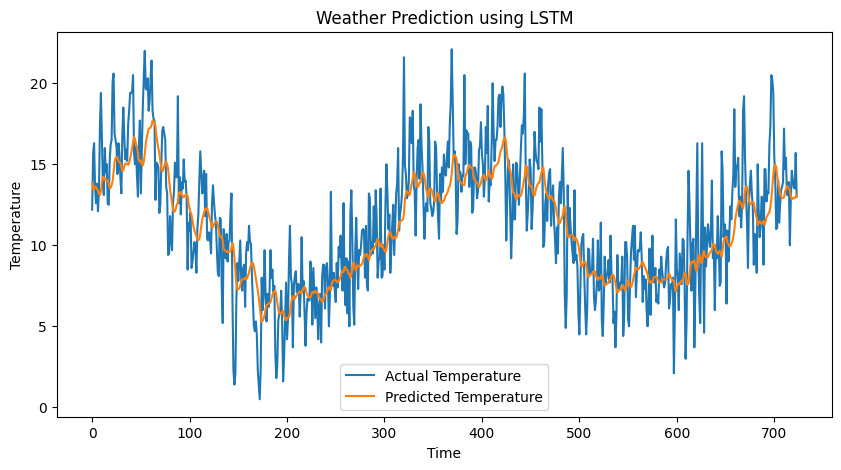

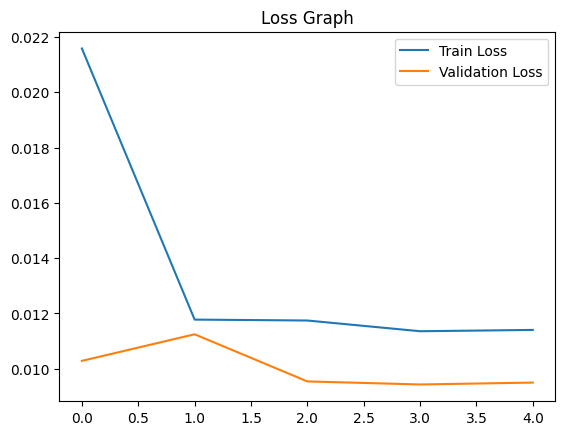

In [ ]:
# ==========================================
# Assignment 10: LSTM for Weather Prediction
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

# ------------------------------------------
# 1. Load Dataset (AUTO DOWNLOAD)
# ------------------------------------------

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv"
df = pd.read_csv(url)

print(df.head())

# Use only temperature column
data = df['Temp'].values.reshape(-1,1)

# ------------------------------------------
# 2. Data Preprocessing
# ------------------------------------------

# Normalize
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

# Create sequences
def create_dataset(data, time_step=30):
    X, y = [], []
    for i in range(time_step, len(data)):
        X.append(data[i-time_step:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

time_step = 30
X, y = create_dataset(scaled_data, time_step)

# Reshape for LSTM
X = X.reshape(X.shape[0], X.shape[1], 1)

# Train-test split
split = int(len(X)*0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print("Preprocessing done")

# ------------------------------------------
# 3. Build LSTM Model
# ------------------------------------------

model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(time_step,1)),
    LSTM(50),
    Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

model.summary()

# ------------------------------------------
# 4. Train Model
# ------------------------------------------

history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test, y_test)
)

# ------------------------------------------
# 5. Predictions
# ------------------------------------------

train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

# Inverse scaling
train_pred = scaler.inverse_transform(train_pred)
test_pred = scaler.inverse_transform(test_pred)

y_train_actual = scaler.inverse_transform(y_train.reshape(-1,1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

# ------------------------------------------
# 6. Evaluation (RMSE)
# ------------------------------------------

from sklearn.metrics import mean_squared_error

train_rmse = np.sqrt(mean_squared_error(y_train_actual, train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test_actual, test_pred))

print("\nTrain RMSE:", train_rmse)
print("Test RMSE :", test_rmse)

# ------------------------------------------
# 7. Visualization: Prediction vs Actual
# ------------------------------------------

plt.figure(figsize=(10,5))
plt.plot(y_test_actual, label="Actual Temperature")
plt.plot(test_pred, label="Predicted Temperature")
plt.title("Weather Prediction using LSTM")
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.legend()
plt.show()

# ------------------------------------------
# 8. Loss Graph
# ------------------------------------------

plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Loss Graph")
plt.legend()
plt.show()